## Classificazione di immagine

Usiamo il dataset di MNIST di immagini utilizzato per il riconoscimento di cifre scritte a mano.
Dobbiamo creare un dataset di validation, perchè non possiamo usare il dataet di training anche per fare il tuning dei parametri, perchè altrimenti l'addestramento sarebbe overfittato.

Divideremo il dataset:
- 78,7% per il training;
- 7% per validation;
- 14,3% per il test.

In [ ]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras # keras ci da l'opzione di usare modelli pre-addestrati
# Useremo pytorch, solo stavolta tensorflow

## Caricamento e preparazione dei dati

Keras ha un insieme di dataset che possono essere importati

In [6]:
# Caricamento e preparazione dei dati
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# dataset diviso in training e test; creiamo il set di validazione
x_val = x_train[::12]
y_val = y_train[::12]

x_train = np.delete(x_train, np.arange(0, x_train.shape[0], 12),0)
y_train = np.delete(y_train, np.arange(0, y_train.shape[0], 12),0)
# i dati vanno cancellati dal train set chiaramente.
# Keras lavora con float32, e vuole che tutti i dati abbiano 4 dimensioni: La prima serve ad accedere ad un'immagine del dataset, poi riga e colonna e infine il canale

# dobbiamo fare un reshape nel formate Channel_Last

img_rows, img_cols, img_channels = 28,28,1
x_train = np.reshape(x_train, (55000, img_rows, img_cols, img_channels))
x_val = np.reshape(x_val, (5000, img_rows, img_cols, img_channels))
x_test = np.reshape(x_test, (10000, img_rows, img_cols, img_channels))

# conversione a float e normalizzazione
x_train = np.float32(x_train)/255
x_val = np.float32(x_val)/255
x_test = np.float32(x_test)/255

#Dobbiamo cambiare il formato delle etichette. Keras usa un formato 'categorical', che lo converte in one-hot
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)



## Definizione dell'architettura della rete neurale

Vediamo come si definisce l'architettura di rete, implementando LeNet. L'architettura da definire è formata da una sequenza di layer di diverso tipo. Per definire ogni tipo di layer, la libreria Keras mette a disposizione una funzione del modulo keras.layers. Iniziamo ad istanziare l'oggetto keras.models.Sequential che rappresenta l'intera architettura a cui aggiungeremo man mano i vari strati tramite il metodo add.

**Softmax**:
Garantisce che i valori siano positivi e a somma unitaria; Quindi questi output si possono interpretare come probabilità di una certa classe.

In [10]:
# Definizione Architettura

lenet = keras.models.Sequential()

lenet.add(keras.layers.Conv2D(6, kernel_size=(5,5), padding='same',activation='relu', input_shape=(img_rows, img_cols, img_channels)))
#input shape serve solo per il primo livello
lenet.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
lenet.add(keras.layers.Conv2D(16, kernel_size=(5,5), padding='same',activation='relu'))
lenet.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
lenet.add(keras.layers.Flatten()) # vettore di 400 features, dobbiamo passare a 120
lenet.add(keras.layers.Dense(120, activation='relu'))
lenet.add(keras.layers.Dense(84, activation='relu'))
lenet.add(keras.layers.Dense(num_classes, activation='softmax'))
lenet.summary() # tabella descrittiva di tutta la rete

# il 95% dei parametri è appreso nella parte fully connected

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        94,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,786 (421.04 KB)

 Trainable params: 107,786 (421.04 KB)

 Non-trainable params: 0 (0.00 B)

## Addestramento

Usiamo la cross-entropy loss, e poi serve l'algoritmo che fa trovare il minimo della funzione, ovvero stochastic gradient descend. Vogliamo usare come metrica l'accuracy.

__Epoca__:
Trascorre un'epoca ogni volta che viene visto tutto il dataset.

In [12]:
# Addestramento
lenet.compile(loss = keras.losses.categorical_crossentropy, optimizer=keras.optimizers.SGD(), metrics=['accuracy'])
lenet.fit(x_train, y_train, batch_size=200, epochs=10, verbose=1, validation_data=(x_val, y_val))

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2021 - loss: 2.2184 - val_accuracy: 0.7096 - val_loss: 0.9825
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8055 - loss: 0.6505 - val_accuracy: 0.8510 - val_loss: 0.4702
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9051 - loss: 0.3227 - val_accuracy: 0.8930 - val_loss: 0.3584
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9233 - loss: 0.2576 - val_accuracy: 0.9042 - val_loss: 0.3039
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9380 - loss: 0.2068 - val_accuracy: 0.9214 - val_loss: 0.2602
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9465 - loss: 0.1747 - val_accuracy: 0.9294 - val_loss: 0.2324
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9562 - loss: 0.1506 - val_accuracy: 0.9320 - val_loss: 0.2276
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9571 - loss: 0.1397 - val_accuracy: 0.

## Valutazione delle Performances

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
vettore delle probabilità predette:  [[2.0863513e-06 8.0487349e-05 7.0300221e-06 8.5638389e-03 3.4475228e-04
  1.1650996e-04 5.1979939e-08 1.6055727e-02 1.2571332e-05 9.7481698e-01]]


Text(0.5, 1.0, 'etichetta vera: 9; Etichetta predetta: 9')

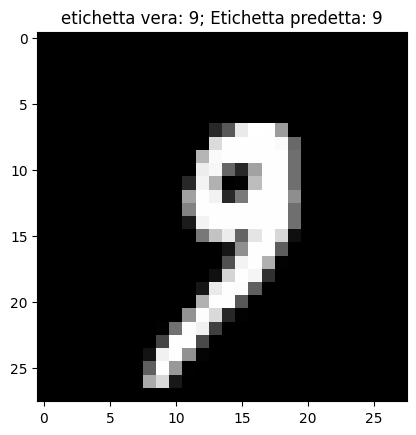

In [14]:
ID = 1000 # indice dell'immagine da analizzare
img = x_test[ID]
label = y_test[ID]
img = np.reshape(img, (-1, img_rows, img_cols, img_channels))
pred = lenet.predict(img)
print('vettore delle probabilità predette: ', pred)
plt.figure()
plt.imshow(img[0,:,:,0], cmap='gray', clim=[0,1])
plt.title('etichetta vera: %d; Etichetta predetta: %d' % (np.argmax(label), np.argmax(pred)))